# 040304: mean-reversion strategy on a toy USD swap

Ported from gs_quant's `040304_strategy_mean_reversion` notebook (DESIGN.md Appendix B), pricing
against the deterministic toy USD rates world (`tests/toylib/rates.py`) instead of a live ARBS
market, so it is self-contained and runs in CI. From `action = ...` onwards the code is the same
as the gs notebook: buy/sell 10y USD payers whenever the toy par rate strays from its own rolling
mean.

In [1]:
from datetime import date

import pandas as pd

from pricebt.backtests.actions import AddTradeAction
from pricebt.backtests.data_sources import GenericDataSource, MissingDataStrategy
from pricebt.backtests.generic_engine import GenericEngine
from pricebt.backtests.strategy import Strategy
from pricebt.backtests.triggers import MeanReversionTrigger, MeanReversionTriggerRequirements
from pricebt.common import Currency, PayReceive
from pricebt.data import measure_series
from pricebt.instrument import IRSwap
from pricebt.risk import Price
from pricebt.session import PricebtSession

PricebtSession.use(assets=["tests/assets/toy_usd_irs.yaml"])    # replaces GsSession.use(...)

Fixed dates rather than `datetime.today()`: the toy rates world has no notion of "today", and a
notebook committed to the repo must produce the same result every time it is run.

In [2]:
start_date = date(2024, 1, 2)
end_date = date(2025, 1, 2)

swap = IRSwap(pay_or_receive=PayReceive.Pay, termination_date='10y', notional_currency=Currency.USD,
              notional_amount=1e4, fixed_rate='ATM', name='swap_10y')

Replaces the GS `Dataset`: the 10y par rate (bp) of a fresh ATM 10y swap on every business day.

In [3]:
s = measure_series(IRSwap(termination_date='10y', notional_currency='USD'), 'par_rate', start_date, end_date, frequency='1b')

In [4]:
action = AddTradeAction(swap)
data_source = GenericDataSource(s, MissingDataStrategy.fill_forward)
z_score_bound = 2
rolling_mean_window = 30
rolling_std_window = 30
trig_req = MeanReversionTriggerRequirements(data_source, z_score_bound, rolling_mean_window, rolling_std_window)
trigger = MeanReversionTrigger(trig_req, action)
strategy = Strategy(None, trigger)

GE = GenericEngine()
backtest = GE.run_backtest(strategy, start=start_date, end=end_date, frequency='1b', show_progress=True)
backtest.trade_ledger()

pricebt: 100%|████████████████████████████| 788/788 [00:00<00:00, 8909.16step/s]

,Open,Close,Open Value,Close Value,Long Short,Status,Trade PnL
Action1_swap_10y_2024-01-04,2024-01-04,None,0.0,0,-1,open,None
Action1_swap_10y_2024-02-23,2024-02-23,None,0.0,0,-1,open,None
Action1_swap_10y_2024-02-29,2024-02-29,None,0.0,0,-1,open,None
Action1_swap_10y_2024-08-19,2024-08-19,None,0.0,0,-1,open,None
Action1_swap_10y_2024-08-23,2024-08-23,None,0.0,0,-1,open,None


In [5]:
backtest.result_summary

,Price,Cumulative Cash,Transaction Costs,Total
2024-01-02,0.000000,0.0,0.0,0.000000
2024-01-03,0.000000,0.0,0.0,0.000000
2024-01-04,0.000000,0.0,0.0,0.000000
2024-01-05,-12.120377,0.0,0.0,-12.120377
2024-01-08,-23.797582,0.0,0.0,-23.797582
...,...,...,...,...
2024-12-27,-3269.351708,0.0,0.0,-3269.351708
2024-12-30,-3278.795811,0.0,0.0,-3278.795811
2024-12-31,-3287.165402,0.0,0.0,-3287.165402
2025-01-01,-3295.149214,0.0,0.0,-3295.149214


<Axes: title={'center': 'Performance'}>

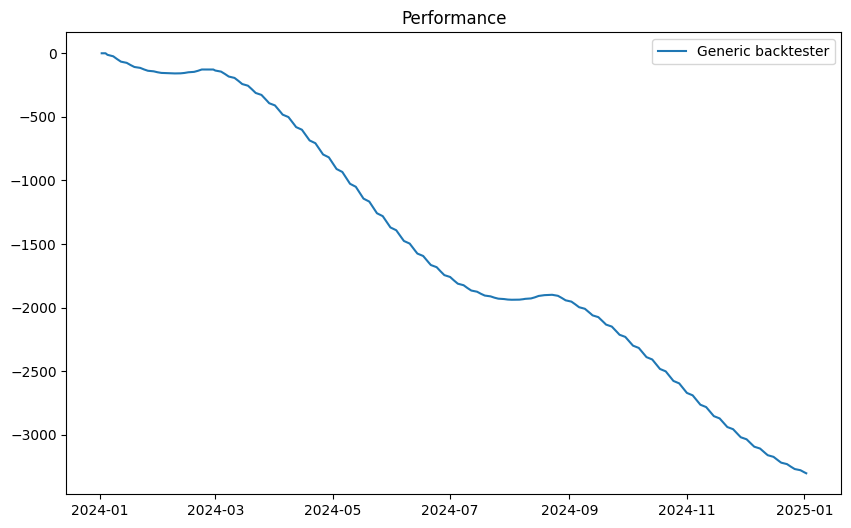

In [6]:
pd.DataFrame({'Generic backtester': backtest.result_summary['Cumulative Cash'] + backtest.result_summary[Price]}).plot(
    figsize=(10, 6), title='Performance')